In [1]:
import os

import deepxde as dde
from deepxde.backend import tf
import numpy as np
import matplotlib.pyplot as plt
import torch

2026-08-05 01:13:56.080227: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-05 01:13:56.110400: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-05 01:13:56.110439: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-05 01:13:56.111455: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-05 01:13:56.117106: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-05 01:13:56.117542: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [3]:
os.environ["DDE_BACKEND"] = "tensorflow"

In [4]:
print(os.environ["DDE_BACKEND"])

tensorflow


In [15]:
geom = dde.geometry.Interval(0, 1)
timedomain = dde.geometry.TimeDomain(0, 1.0)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

In [16]:
a = 0.4
def pde(x, y):
    du_dt = dde.grad.jacobian(y, x, i=0, j=1)
    du_xx = dde.grad.hessian(y, x, component=0, i=0, j=0)
    return du_dt - a*du_xx 

In [17]:
def is_on_boundary(x, on_boundary):
    if not on_boundary:
        return False

    return dde.utils.isclose(x[0], 0) or dde.utils.isclose(x[0], 1)

def boundary_value(x):
    return 

In [20]:
bc = dde.icbc.DirichletBC(geomtime, lambda x : 2*x[:, 0:1], is_on_boundary)

ic = dde.icbc.IC(geomtime, lambda x : np.sin(np.pi * x[:, 0:1]), lambda x, on_initial : on_initial)

In [21]:
data = dde.data.TimePDE(geomtime, pde, [bc, ic], num_domain=2540, num_boundary=80, num_initial=160, num_test=2540)

In [22]:
layer_size = [2] + [20]*3 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)
model = dde.Model(data, net)

In [23]:
model.compile("adam", lr=0.001)

Compiling model...
'compile' took 0.006813 s



In [24]:
losshistory, train_state = model.train(iterations=15000)

Training model...



/media/srimukha-sarma/Windows-SSD/conda-envs/deepxde/lib/python3.11/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


Cause: could not parse the source code of <function <lambda> at 0x7b1ec5a679c0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7b1ec5a679c0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the sourc

In [26]:
model.compile("L-BFGS")
dde.optimizers.config.set_LBFGS_options(maxiter=15000)
losshistory, train_state = model.train()

Compiling model...
'compile' took 0.000650 s

Training model...

Step      Train loss                        Test loss                         Test metric
15000     [3.13e-02, 1.17e-02, 4.33e-03]    [8.59e-03, 1.17e-02, 4.33e-03]    []  
15844     [1.40e-03, 5.83e-04, 6.56e-04]    [7.64e-04, 5.83e-04, 6.56e-04]    []  

Best model at step 15844:
  train loss: 2.64e-03
  test loss: 2.00e-03
  test metric: []

'train' took 122.778266 s



Saving loss history to /media/srimukha-sarma/Windows-SSD/TRON/loss.dat ...
Saving training data to /media/srimukha-sarma/Windows-SSD/TRON/train.dat ...
Saving test data to /media/srimukha-sarma/Windows-SSD/TRON/test.dat ...


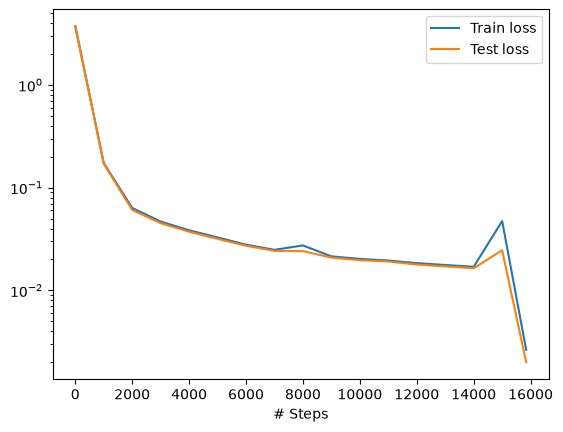

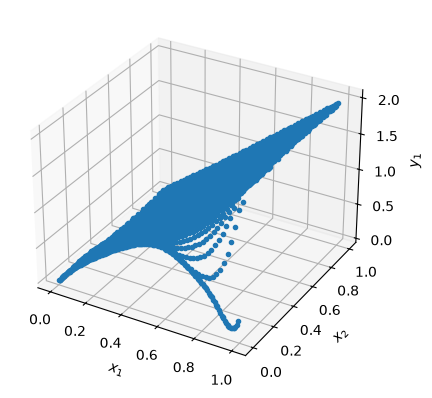

In [27]:
dde.saveplot(losshistory, train_state, issave=True, isplot=True)